# Khởi tạo  

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = sns.load_dataset("iris")

print("5 dòng đầu tiên:")
display(df.head()) 

print("\nKích thước ma trận dữ liệu (Shape):", df.shape)

5 dòng đầu tiên:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Kích thước ma trận dữ liệu (Shape): (150, 5)


# Phần 1 — Thống kê mô tả & đặc trưng

In [8]:
# 1. Thống kê mô tả toàn bộ ma trận dữ liệu
print("--- THỐNG KÊ MÔ TẢ CHUNG ---")
display(df.describe())

numeric_df = df.select_dtypes(include=[np.number])

print("\nPhương sai (Variance):")
display(numeric_df.var())

IQR = numeric_df.quantile(0.75) - numeric_df.quantile(0.25)

print("\nKhoảng tứ phân vị (IQR):")
display(IQR)

print("\n--- THỐNG KÊ THEO NHÓM (SPECIES) ---")

group_stats = df.groupby('species').agg(['mean', 'std'])
display(group_stats)

--- THỐNG KÊ MÔ TẢ CHUNG ---


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000



Phương sai (Variance):


sepal_length    0.685694
sepal_width     0.189979
petal_length    3.116278
petal_width     0.581006
dtype: float64


Khoảng tứ phân vị (IQR):


sepal_length    1.3
sepal_width     0.5
petal_length    3.5
petal_width     1.5
dtype: float64


--- THỐNG KÊ THEO NHÓM (SPECIES) ---


sepal_length           sepal_width           petal_length  \
                   mean       std        mean       std         mean   
species                                                                
setosa            5.006  0.352490       3.428  0.379064        1.462   
versicolor        5.936  0.516171       2.770  0.313798        4.260   
virginica         6.588  0.635880       2.974  0.322497        5.552   

                     petal_width            
                 std        mean       std  
species                                     
setosa      0.173664       0.246  0.105386  
versicolor  0.469911       1.326  0.197753  
virginica   0.551895       2.026  0.274650

# Phần 2 — Phân phối xác suất

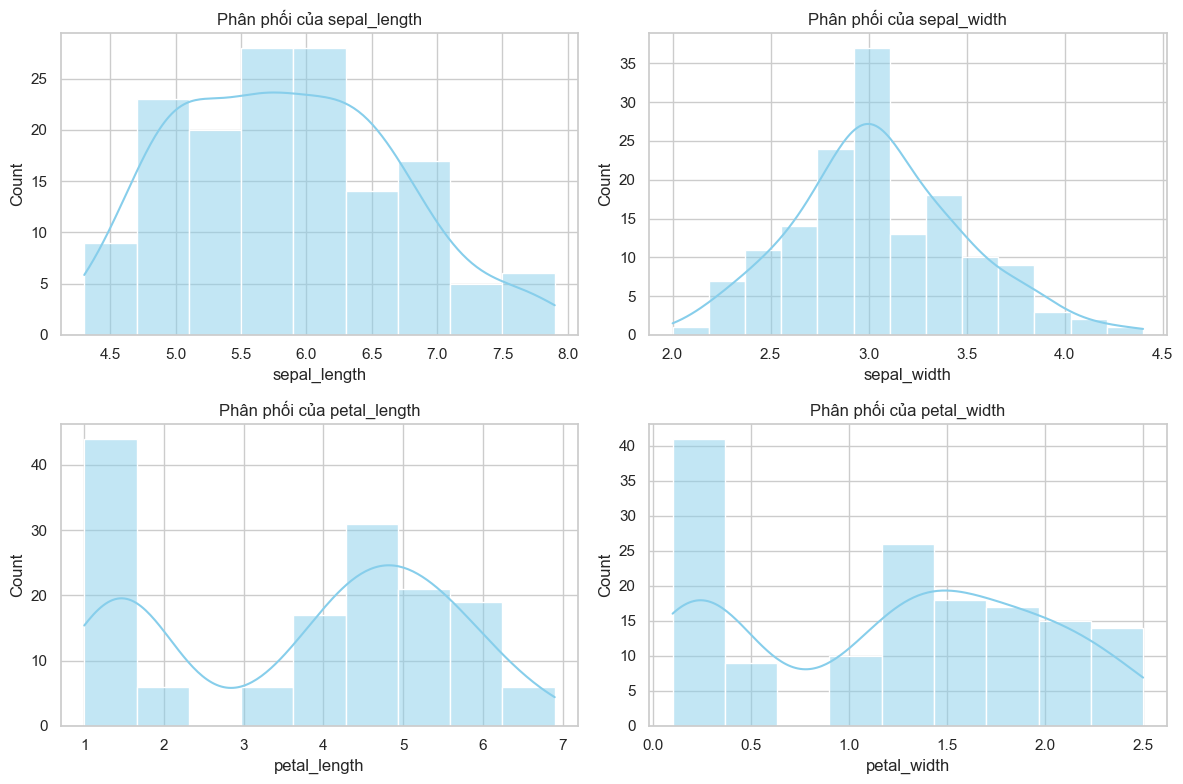

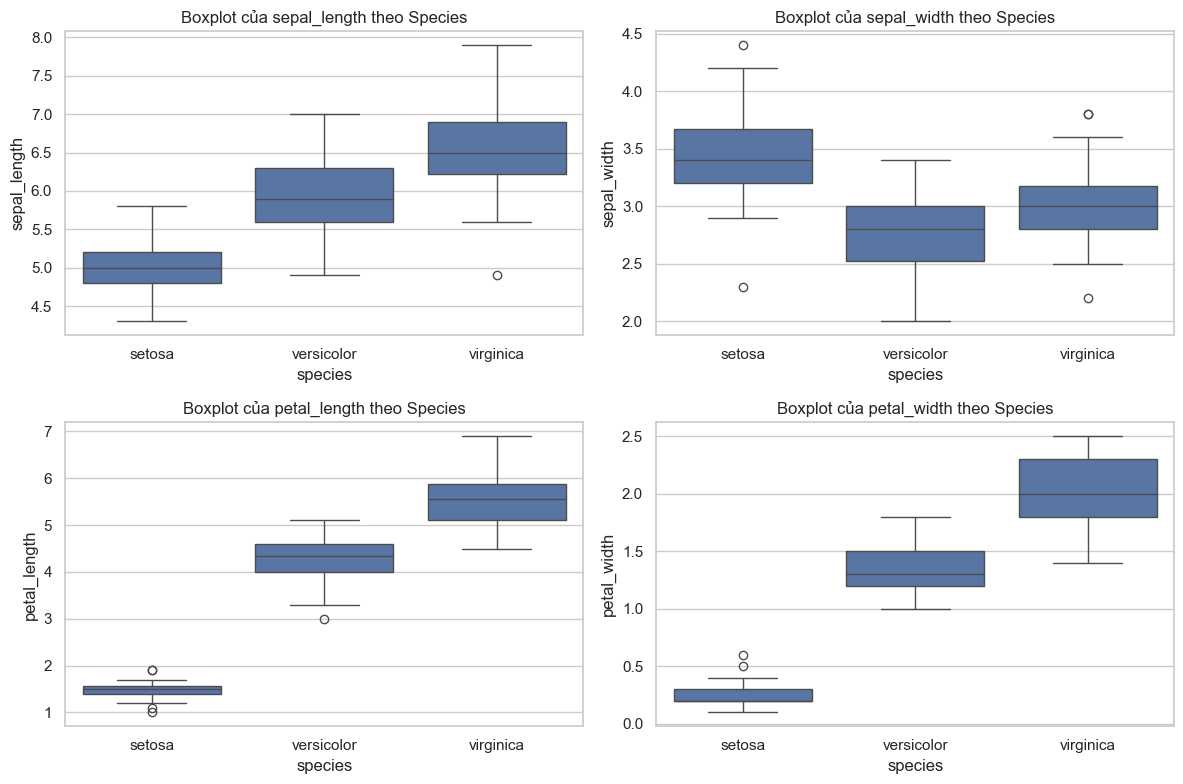

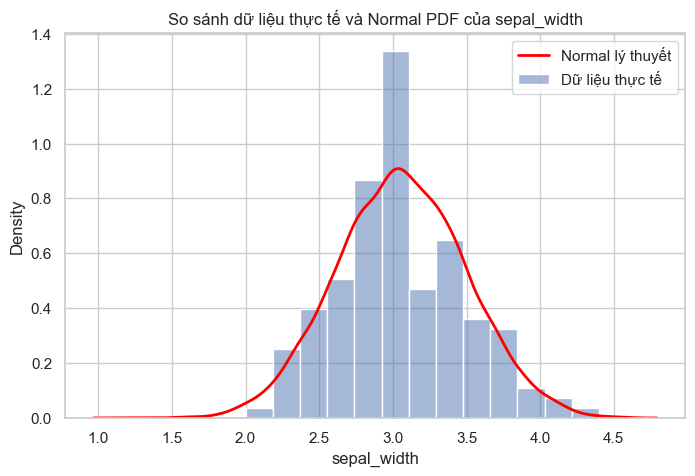

In [9]:
# 1. Vẽ Histogram + KDE (Kernel Density Estimation)
plt.figure(figsize=(12, 8))
for i, col in enumerate(numeric_df.columns, 1):
    plt.subplot(2, 2, i)
    sns.histplot(data=df, x=col, kde=True, color='skyblue')
    plt.title(f'Phân phối của {col}')
plt.tight_layout()
plt.show()

# 2. Vẽ Boxplot
plt.figure(figsize=(12, 8))
for i, col in enumerate(numeric_df.columns, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df, x='species', y=col)
    plt.title(f'Boxplot của {col} theo Species')
plt.tight_layout()
plt.show()

# Mô phỏng phân phối chuẩn
feature_to_sim = 'sepal_width' 
mu = df[feature_to_sim].mean()
sigma = df[feature_to_sim].std()

# Sinh 10,000 mẫu ngẫu nhiên từ phân phối chuẩn N(mu, sigma^2)
simulated_data = np.random.normal(mu, sigma, 10000)

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x=feature_to_sim, stat='density', alpha=0.5, label='Dữ liệu thực tế')
sns.kdeplot(simulated_data, color='red', linewidth=2, label='Normal lý thuyết')
plt.legend()
plt.title(f'So sánh dữ liệu thực tế và Normal PDF của {feature_to_sim}')
plt.show()

### Nhận xét Phần 2
* **Hình dạng Histogram:** Biến `sepal_width` có phân phối khá giống phân phối chuẩn (hình quả chuông, đối xứng). Trong khi đó, `petal_length` có hình dạng đa đỉnh (bimodal/multimodal), chứng tỏ có sự pha trộn giữa các cụm (loài) khác nhau.
* **Mức độ khớp (Mô phỏng):** Đường Normal lý thuyết màu đỏ khá khớp với phân phối của dữ liệu thực tế (`sepal_width`), chứng tỏ giả định phân phối chuẩn trên biến này là hợp lý để dùng cho các mô hình AI (như Gaussian Naive Bayes).

# Phần 3 — Phân tích đa biến & tương quan

Ma trận hiệp phương sai (Covariance):


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,0.685694,-0.042434,1.274315,0.516271
sepal_width,-0.042434,0.189979,-0.329656,-0.121639
petal_length,1.274315,-0.329656,3.116278,1.295609
petal_width,0.516271,-0.121639,1.295609,0.581006


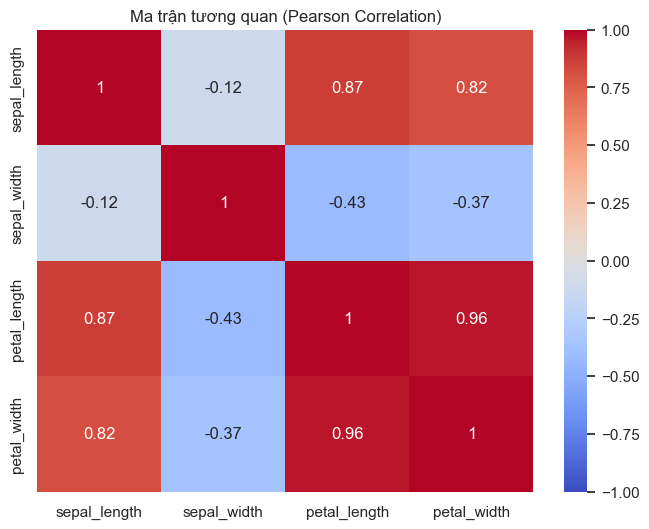

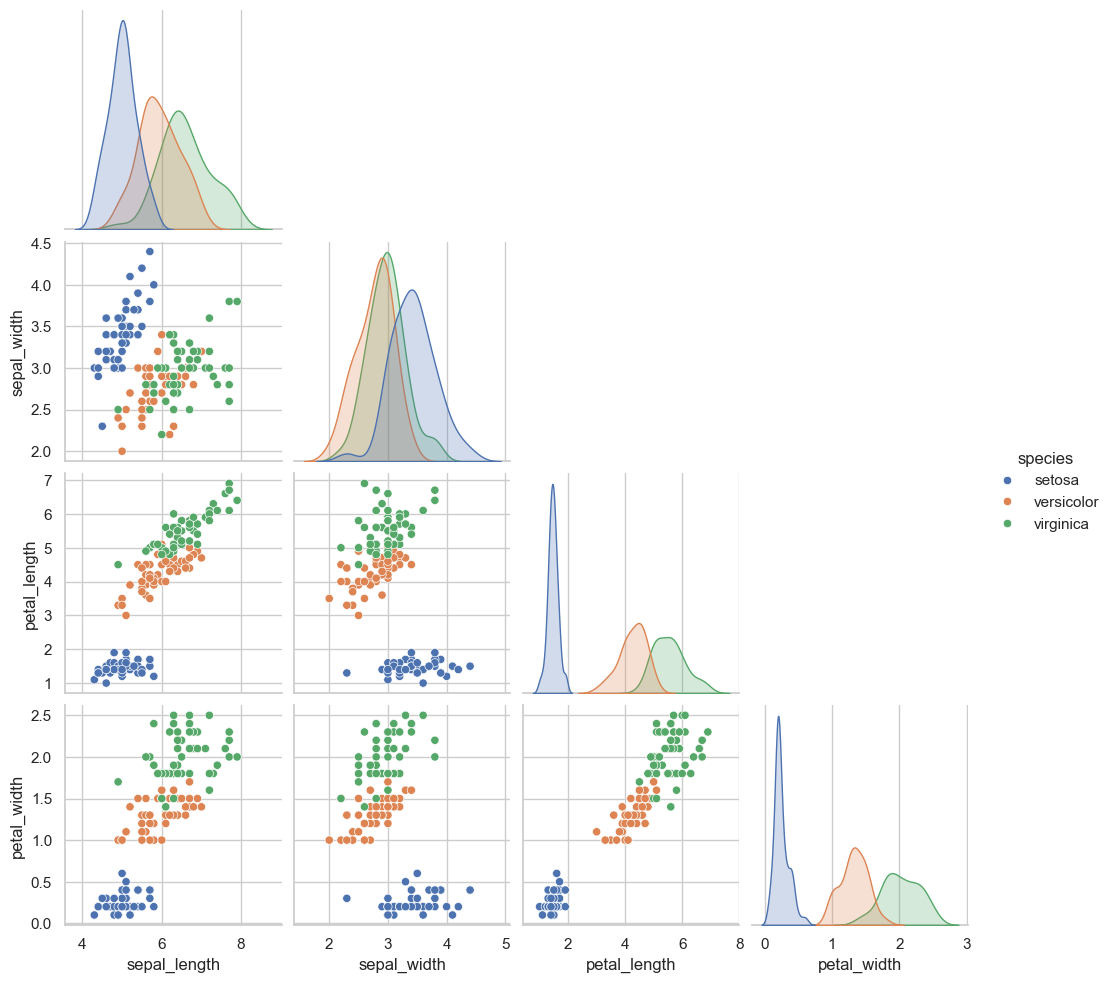

In [10]:
# 1. Tính ma trận hiệp phương sai và tương quan
cov_matrix = numeric_df.cov()
cor_matrix = numeric_df.corr()

print("Ma trận hiệp phương sai (Covariance):")
display(cov_matrix)

# 2. Vẽ Heatmap tương quan
plt.figure(figsize=(8, 6))
sns.heatmap(cor_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Ma trận tương quan (Pearson Correlation)")
plt.show()

# 3. Vẽ Pairplot
sns.pairplot(df, hue='species', corner=True) 
plt.show()

### Nhận xét Phần 3
* **Cặp biến tương quan mạnh nhất:** Dựa vào Heatmap, cặp biến `petal_length` và `petal_width` có hệ số tương quan dương cực kỳ cao ($\approx 0.96$). 
* **Dấu hiệu Đa cộng tuyến:** Có xảy ra hiện tượng đa cộng tuyến mạnh giữa chiều dài và chiều rộng của cánh hoa. Nếu đưa vào mô hình Hồi quy tuyến tính (Linear Regression), ma trận đặc trưng sẽ kém khả nghịch, ta có thể cân nhắc loại bỏ bớt 1 trong 2 biến.
* **Nhận xét Pairplot:** Loài `setosa` luôn nằm tách biệt hẳn (cụm màu xanh dương) với 2 loài còn lại trên hầu hết các không gian 2D.

# Phần 4 — Xác suất & Định lý Bayes

Xác suất mắc bệnh thực sự khi test dương tính (với tỷ lệ mắc 0.01) là: 0.1667


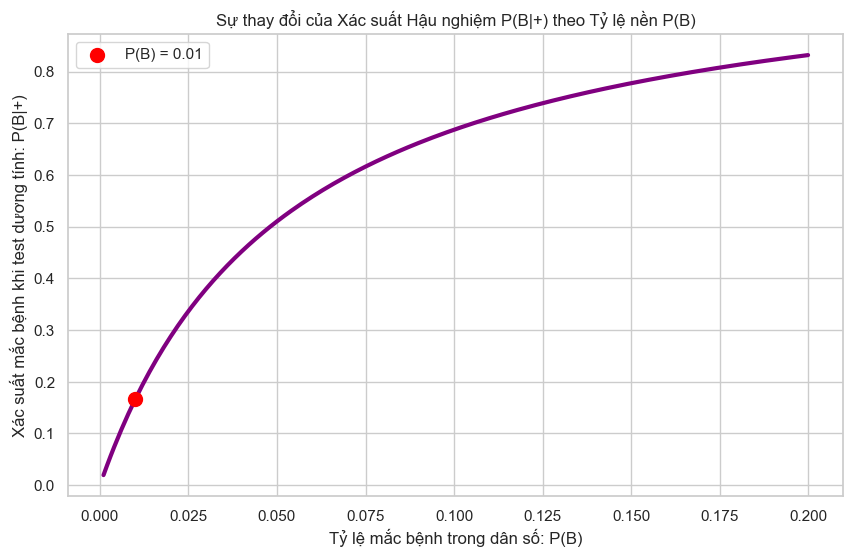

In [11]:
P_pos_givenB = 0.99  # Độ nhạy: P(+|B)
P_pos_givenNB = 0.05 # Dương tính giả: P(+|~B)

# 1. Tính cho P(B) = 0.01
P_B_single = 0.01
P_pos_single = (P_pos_givenB * P_B_single) + (P_pos_givenNB * (1 - P_B_single))
P_B_given_pos_single = (P_pos_givenB * P_B_single) / P_pos_single
print(f"Xác suất mắc bệnh thực sự khi test dương tính (với tỷ lệ mắc 0.01) là: {P_B_given_pos_single:.4f}")

# 2. Khảo sát tỉ lệ mắc bệnh từ 0.001 đến 0.2
# TODO: Tạo mảng vector từ 0.001 đến 0.2 bằng np.linspace, lấy 200 điểm
P_B_array = np.linspace(0.001, 0.2, 200)

# Áp dụng công thức Bayes bằng toán tử ma trận (Broadcasting)
P_pos_array = (P_pos_givenB * P_B_array) + (P_pos_givenNB * (1 - P_B_array))
P_B_given_pos_array = (P_pos_givenB * P_B_array) / P_pos_array

# Trực quan hóa
plt.figure(figsize=(10, 6))
plt.plot(P_B_array, P_B_given_pos_array, color='purple', linewidth=3)
# Đánh dấu điểm mặc định của đề bài
plt.scatter(0.01, P_B_given_pos_single, color='red', s=100, zorder=5, label='P(B) = 0.01')

plt.title("Sự thay đổi của Xác suất Hậu nghiệm P(B|+) theo Tỷ lệ nền P(B)")
plt.xlabel("Tỷ lệ mắc bệnh trong dân số: P(B)")
plt.ylabel("Xác suất mắc bệnh khi test dương tính: P(B|+)")
plt.legend()
plt.grid(True)
plt.show()

### Nhận xét Phần 4 (Nghịch lý Bệnh hiếm - Base Rate Fallacy)
* **Kết quả tính toán:** Mặc dù máy móc (xét nghiệm) có độ chính xác rất cao lên tới $99\%$, nhưng xác suất một người thực sự mắc bệnh khi nhận kết quả dương tính chỉ xấp xỉ $\sim 16.5\%$.
* **Trực giác Toán học:** Sự "phản trực giác" này xảy ra do **Tỷ lệ nền (Base rate)** $P(B) = 0.01$ quá nhỏ. Trong quần thể 10.000 người, chỉ có 100 người thực sự bệnh. Khi xét nghiệm cho 9.900 người không bệnh, mức dương tính giả $5\%$ sẽ tạo ra tới 495 ca dương tính sai. Số lượng "dương tính giả" áp đảo hoàn toàn số lượng "dương tính thật" (99 người), dẫn đến niềm tin hậu nghiệm $P(B|+)$ bị kéo xuống rất thấp.